Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Data Cleaning & Preprocessing

In [4]:

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")


df = df.drop(['EmployeeNumber','Over18','StandardHours'], axis=1)


df = pd.get_dummies(df, drop_first=True)


X = df.drop('Attrition_Yes', axis=1)
y = df['Attrition_Yes']


In [5]:
print(df.columns)


Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Yes',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Di

Train-Test Split



In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train Multiple Models

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {results[name]:.2f}")
    print(classification_report(y_test, y_pred))
    print("-"*50)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.86
              precision    recall  f1-score   support

       False       0.88      0.97      0.92       255
        True       0.43      0.15      0.23        39

    accuracy                           0.86       294
   macro avg       0.66      0.56      0.57       294
weighted avg       0.82      0.86      0.83       294

--------------------------------------------------
Decision Tree Accuracy: 0.75
              precision    recall  f1-score   support

       False       0.88      0.83      0.85       255
        True       0.17      0.23      0.20        39

    accuracy                           0.75       294
   macro avg       0.52      0.53      0.53       294
weighted avg       0.78      0.75      0.77       294

--------------------------------------------------
Random Forest Accuracy: 0.87
              precision    recall  f1-score   support

       False       0.88      0.99      0.93       255
        True       0.57      0.10      0.1

Feature Importance (Random Forest)

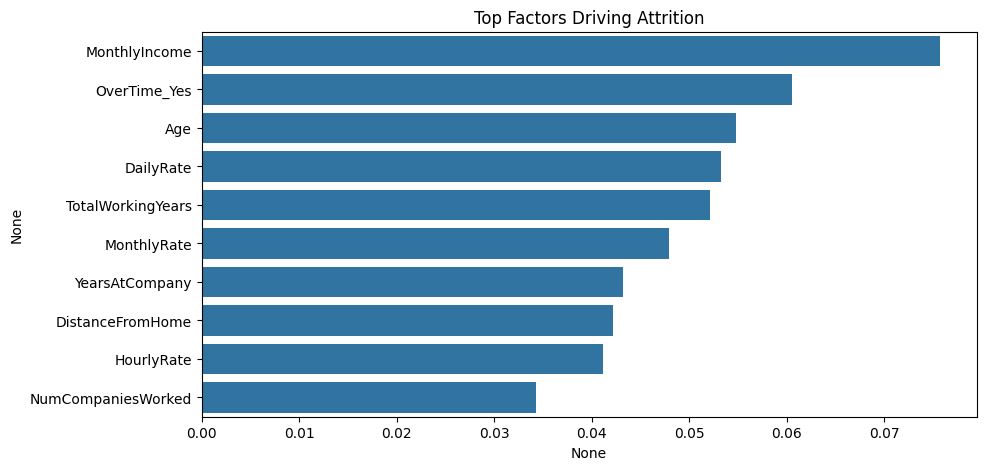

In [8]:
importance = pd.Series(models["Random Forest"].feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top Factors Driving Attrition")
plt.show()


In [9]:
import os

# Create a folder named "Charts" if it doesn't exist
if not os.path.exists("Charts"):
    os.makedirs("Charts")


 Visualization

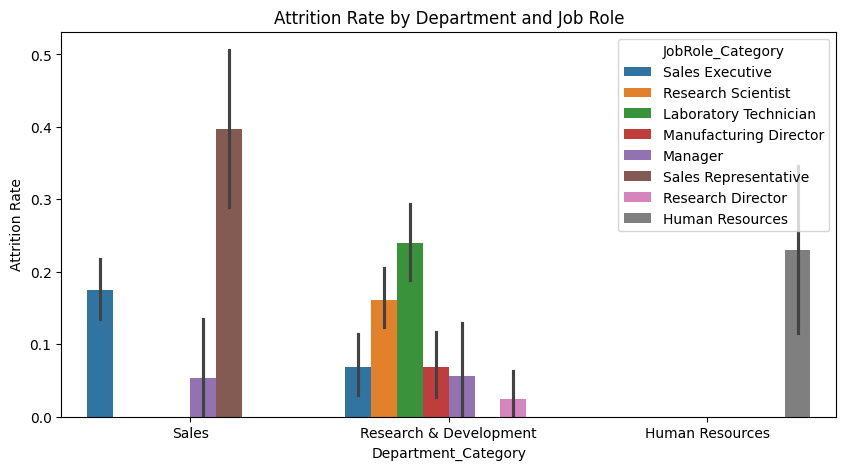

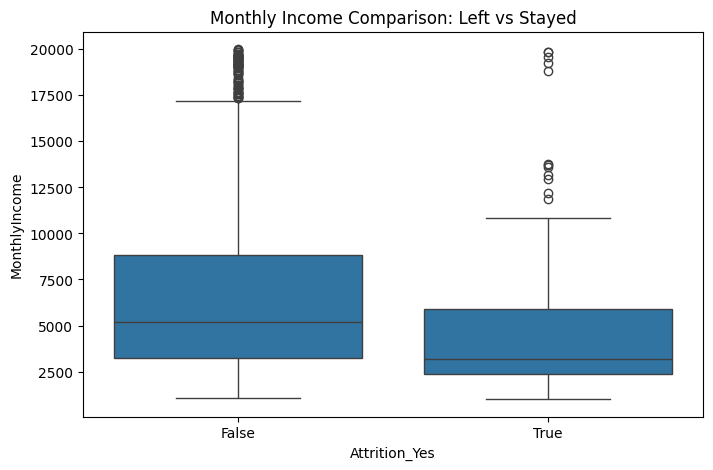

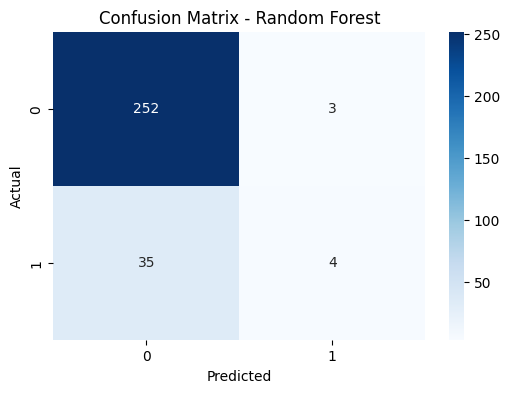

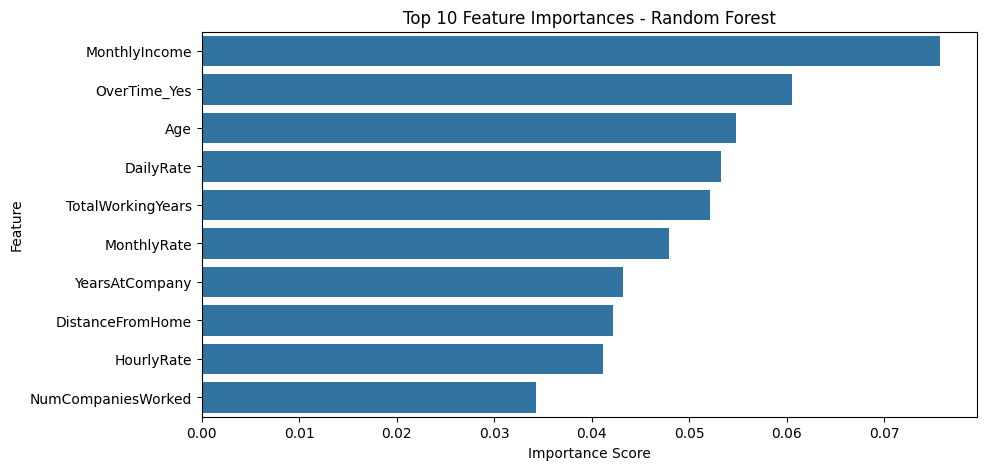

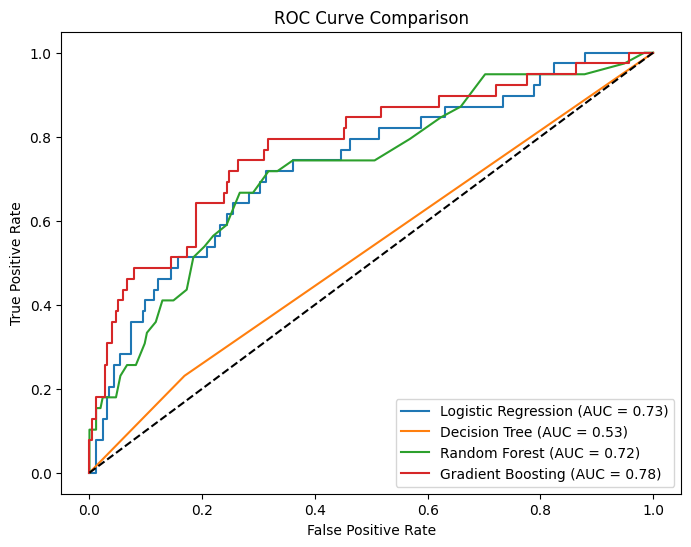

In [10]:
from sklearn.metrics import roc_curve, auc # Added import

# Identify the best model and its predictions for Chart 3, 4, 5
# Assuming 'results' and 'models' are available from previous cell execution
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)


# --- Chart 1: Attrition Rate by Department and Job Role ---

plot_df_chart1 = df.copy()
plot_df_chart1['Department_Category'] = 'Human Resources' # Default for the dropped category
plot_df_chart1.loc[plot_df_chart1['Department_Research & Development'] == 1, 'Department_Category'] = 'Research & Development'
plot_df_chart1.loc[plot_df_chart1['Department_Sales'] == 1, 'Department_Category'] = 'Sales'

# Reconstruct 'JobRole' column for plotting
job_role_cols = [col for col in df.columns if col.startswith('JobRole_')]

def get_job_role(row):
    for col in job_role_cols:
        if row[col] == 1:
            return col.replace('JobRole_', '')
    return 'Sales Executive' # Assuming 'Sales Executive' was the base category dropped by drop_first=True, or another default

plot_df_chart1['JobRole_Category'] = plot_df_chart1.apply(get_job_role, axis=1)

plt.figure(figsize=(10,5))
sns.barplot(x='Department_Category', y='Attrition_Yes', hue='JobRole_Category', data=plot_df_chart1)
plt.title('Attrition Rate by Department and Job Role')
plt.ylabel('Attrition Rate')
plt.savefig("Charts/chart1_attrition_by_dept_jobrole.png")
plt.show()

# --- Chart 2: Monthly Income Comparison ---

plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition_Yes', y='MonthlyIncome', data=df)
plt.title('Monthly Income Comparison: Left vs Stayed')
plt.savefig("Charts/chart2_income_left_vs_stayed.png")
plt.show()

# --- Chart 3: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}') # Dynamic title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("Charts/chart3_confusion_matrix.png")
plt.show()

# --- Chart 4: Feature Importances ---
importance = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_features, y=top_features.index, orient='h')
plt.title(f'Top 10 Feature Importances - {best_model_name}')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.savefig("Charts/chart4_feature_importances.png")
plt.show()

# --- Chart 5: ROC Curve Comparison ---
plt.figure(figsize=(8,6))
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_pred_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    else:
        print(f"Model {name} does not have predict_proba method and will be skipped for ROC curve.")

plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig("Charts/chart5_roc_curve.png")
plt.show()